In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1).csv


In [6]:
import io

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]), encoding='latin1')

In [7]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.shape

(9800, 18)

In [10]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [11]:
(df.isnull().sum()/len(df))*100

,0
Row_ID,0.000000
Order_ID,0.000000
Order_Date,0.000000
Ship_Date,0.000000
Ship_Mode,0.000000
Customer_ID,0.000000
Customer_Name,0.000000
Segment,0.000000
Country,0.000000
City,0.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [16]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format="%d/%m/%Y")
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], format="%d/%m/%Y")

In [17]:
df.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,datetime64[ns]
Ship_Date,datetime64[ns]
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


In [18]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]

,0
Row_ID,1
Order_ID,CA-2018-100111
Order_Date,2017-09-05 00:00:00
Ship_Date,2018-09-26 00:00:00
Ship_Mode,Standard Class
Customer_ID,WB-21850
Customer_Name,William Brown
Segment,Consumer
Country,United States
City,New York City


In [20]:
# df['Profit Margin %'] = (df['Profit']/df['Sales'])*100 # 'Profit' column not found
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

In [21]:
total_revenue = df['Sales'].sum()
print("Revenue =", total_revenue)

Revenue = 2261536.7827000003


In [23]:
# total_profit = df['Profit'].sum() # 'Profit' column not found
# print("Profit =", total_profit)

In [24]:
avg_order_value = df['Sales'].mean()
print(avg_order_value)

230.7690594591837


In [26]:
# profit_margin = (df['Profit'].sum()/df['Sales'].sum())*100 # 'Profit' column not found
# print(profit_margin)

In [28]:
orders = df['Order_ID'].nunique()
print(orders)

4922


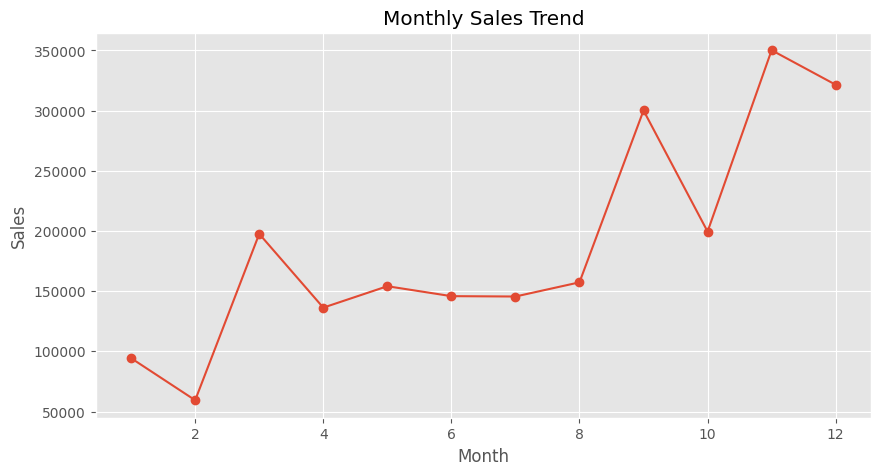

In [29]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

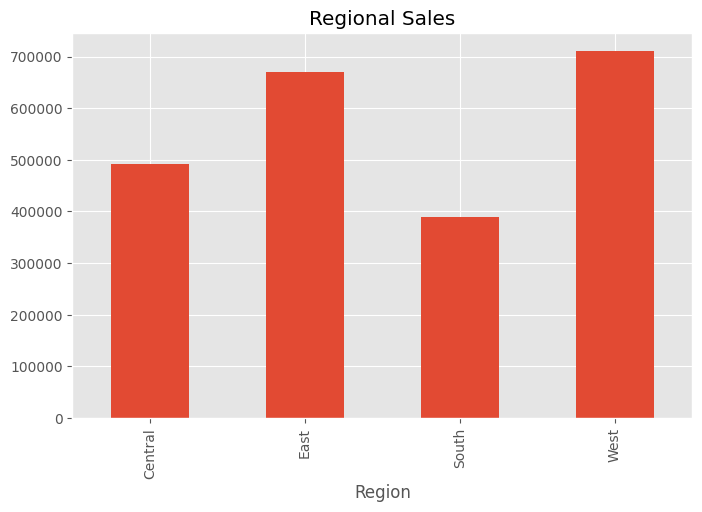

In [30]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Regional Sales')
plt.show()

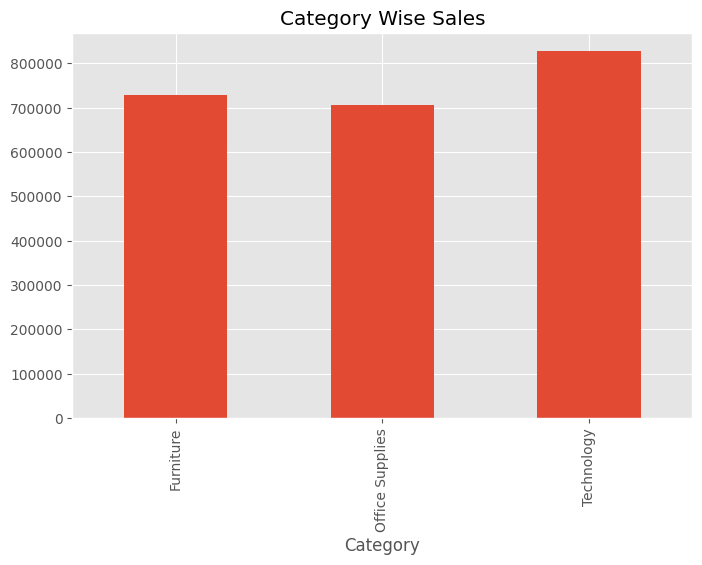

In [31]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Category Wise Sales')
plt.show()

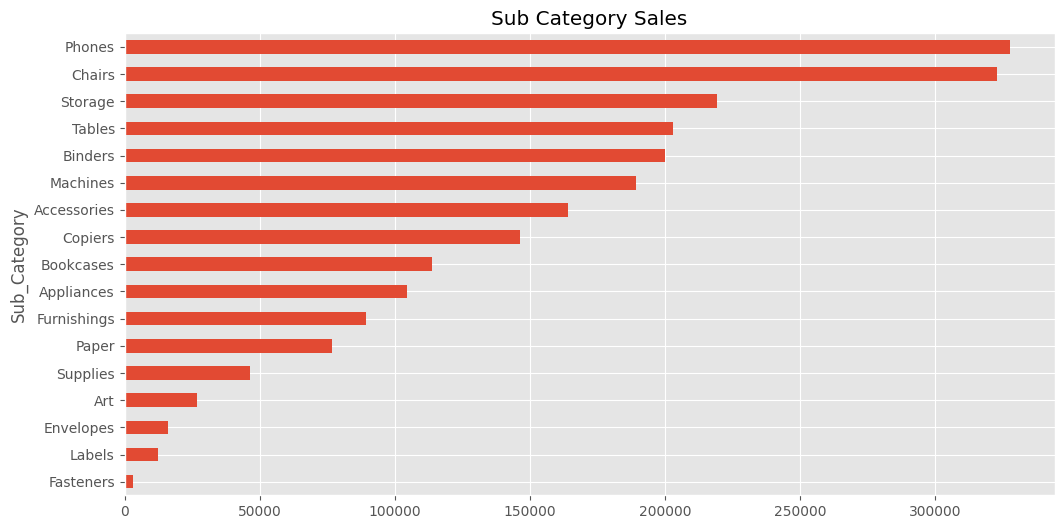

In [33]:
plt.figure(figsize=(12,6))

df.groupby('Sub_Category')['Sales'].sum()\
.sort_values()\
.plot(kind='barh')

plt.title('Sub Category Sales')
plt.show()

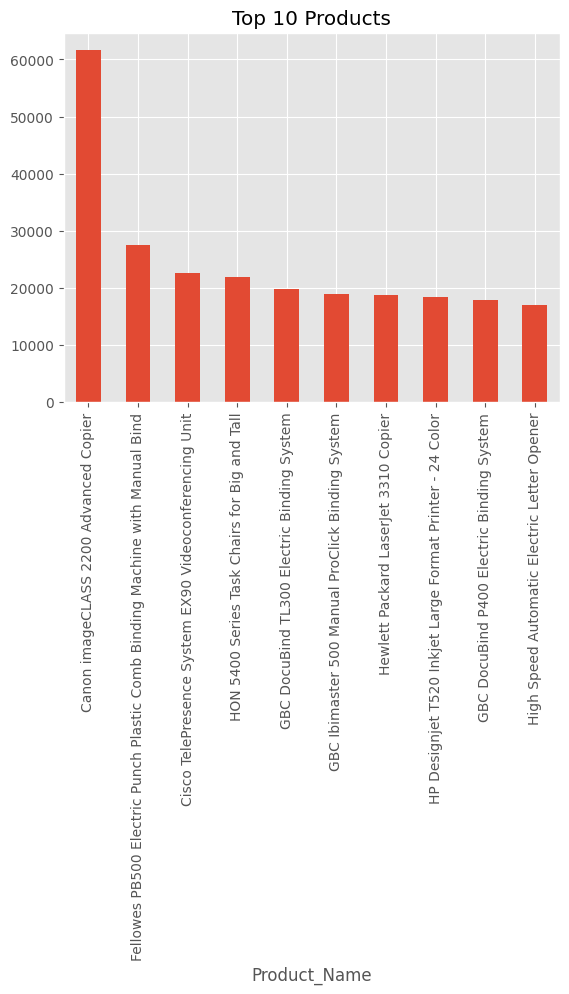

In [35]:
top_products = df.groupby('Product_Name')['Sales']\
.sum()\
.sort_values(ascending=False)\
.head(10)

top_products.plot(kind='bar')

plt.title('Top 10 Products')
plt.show()

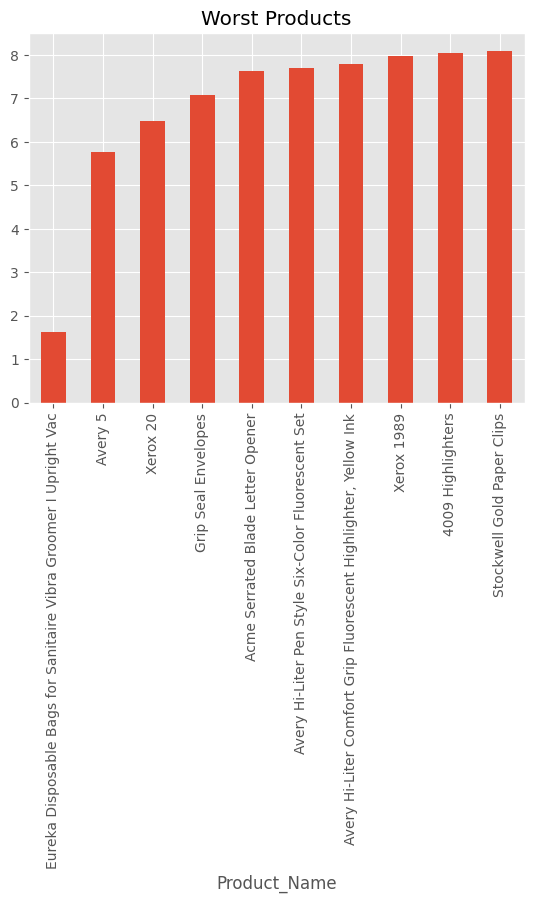

In [37]:
worst_products = df.groupby('Product_Name')['Sales']\
.sum()\
.sort_values()\
.head(10)

worst_products.plot(kind='bar')

plt.title('Worst Products')
plt.show()

In [45]:
# profit_by_category = df.groupby('Category')['Profit'].sum()

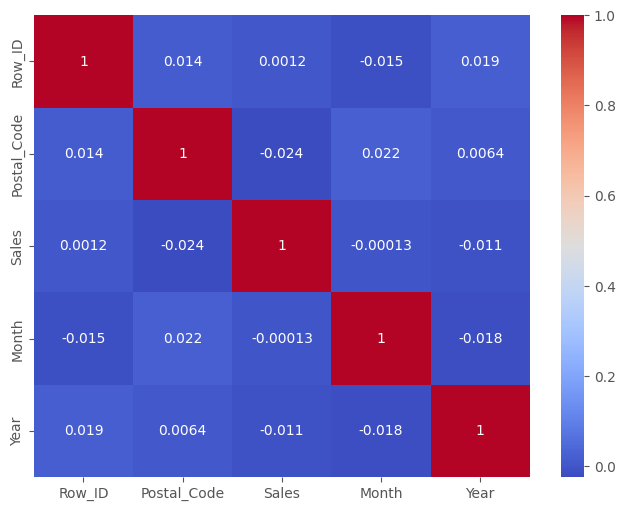

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()